Here we try to get directions for safety and utility on gemma2-2b-it

# imports

In [1]:
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

/home/al-raisi/miniconda3/envs/sfutilproject/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load model and datasets

In [9]:
model_name = "google/gemma-2-2b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

#harmful prompts
advbench = load_dataset("walledai/AdvBench")
harmful_prompts = advbench['train']['prompt']

#harmless prompts
alpaca = load_dataset("tatsu-lab/alpaca")
harmless_prompts = [entry['instruction'] for entry in alpaca['train']]

#utility prompts
helpsteer = load_dataset("nvidia/HelpSteer")
utility_prompts = [entry['prompt'] for entry in helpsteer['train']]

N = 100
harmful_prompts = harmful_prompts[:N]
harmless_prompts = harmless_prompts[:N]
utility_prompts = utility_prompts[:N]

Loading weights: 100%|██████████| 288/288 [00:00<00:00, 5710.47it/s]


# Get activations from all layers 

In [10]:
def get_activations(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return [h[:, -1, :].float().cpu().numpy()[0] for h in outputs.hidden_states]

# store all activations from respective dataset
harmful = np.array([get_activations(prompt) for prompt in tqdm(harmful_prompts, desc="harmful")])
harmless = np.array([get_activations(prompt) for prompt in tqdm(harmless_prompts, desc="harmless")])
utility = np.array([get_activations(prompt) for prompt in tqdm(utility_prompts, desc="utility")])

np.save("harmful_2_2b_activations.npy", harmful)
np.save("harmless_2_2b_activations.npy", harmless)
np.save("utility_2_2b_activations.npy", utility)

utility: 100%|██████████| 100/100 [40:35<00:00, 24.36s/it]


# Implement and apply DoM then use cosine similarity on extracted directions

In [11]:
# all have the same size/shape anyways
num_layers = harmful.shape[1]
cosine_similarities = []

#This is same as what was put previously in EDA.ipynb just modified for all layers
for layer in range(num_layers):
    # mean of activations
    harm_mean = harmful[:, layer, :].mean(axis=0)
    help_mean = utility[:, layer, :].mean(axis=0)
    alp_mean = harmless[:, layer, :].mean(axis=0)

    #DoM here extract safety/utility directions 
    refusal_direction = harm_mean - alp_mean
    utility_direction = help_mean - alp_mean

    #for neater results normalize and also recall with cosine similarity that closer to 0 means closer to being independent
    refusal_direction /= np.linalg.norm(refusal_direction)
    utility_direction /= np.linalg.norm(utility_direction)
    cosine_similarities.append(np.dot(refusal_direction, utility_direction))

# Plots and other stuff

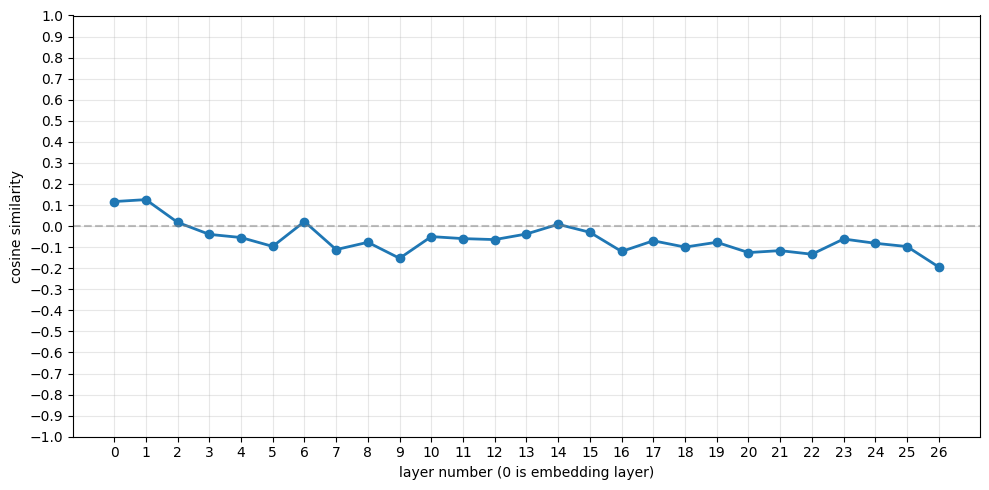

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_layers), cosine_similarities, marker='o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("layer number (0 is embedding layer)")
plt.ylabel("cosine similarity")
plt.xticks(range(0, num_layers, 1))
plt.yticks(np.arange(-1, 1.1, 0.1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [13]:
for i, cos_sim in enumerate(cosine_similarities):
    print(f"layer {i} cosine similarity: {cos_sim:.4f}")

layer 0 cosine similarity: 0.1166
layer 1 cosine similarity: 0.1258
layer 2 cosine similarity: 0.0180
layer 3 cosine similarity: -0.0392
layer 4 cosine similarity: -0.0542
layer 5 cosine similarity: -0.0964
layer 6 cosine similarity: 0.0215
layer 7 cosine similarity: -0.1115
layer 8 cosine similarity: -0.0768
layer 9 cosine similarity: -0.1528
layer 10 cosine similarity: -0.0498
layer 11 cosine similarity: -0.0593
layer 12 cosine similarity: -0.0640
layer 13 cosine similarity: -0.0374
layer 14 cosine similarity: 0.0086
layer 15 cosine similarity: -0.0294
layer 16 cosine similarity: -0.1204
layer 17 cosine similarity: -0.0696
layer 18 cosine similarity: -0.0996
layer 19 cosine similarity: -0.0768
layer 20 cosine similarity: -0.1256
layer 21 cosine similarity: -0.1164
layer 22 cosine similarity: -0.1335
layer 23 cosine similarity: -0.0612
layer 24 cosine similarity: -0.0815
layer 25 cosine similarity: -0.0971
layer 26 cosine similarity: -0.1942


this (intuitively) doesnt seem significant, something to improve here (similarly for mistralit and gemma 2b) 